# Federated AER sandbox — train, assert, latents, prototypes

Runs `fedwater`'s **actual FL protocol** (`fl_training.federated.FPLTrainer` — FedAvg + FPL
hierarchical prototypes over AER) on any world, then interrogates what it produced.

Three questions, three sections:

1. **§5 assert** — are the outputs well-formed and mutually consistent? (latent dim, row counts,
   client/global weight sync after FedAvg, prototypes == eval-mode mean latent).
2. **§6 latents** — is the latent space legible? separability of district / month, per round,
   including the untrained init (`round = -1`).
3. **§7 prototypes** — compiled into one tidy table: local (pre-FedAvg), global (FINCH clusters),
   post-FedAvg; plus drift signals, FINCH cluster counts, client similarity.

Nothing in the protocol is re-implemented — `SnapshotFPLTrainer` only adds latent snapshots via
two hooks. Run from `notebooks/prospection/`.

## 0. Setup

In [1]:
from __future__ import annotations

import copy, json, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore", category=UserWarning)

NB_DIR = Path.cwd()
SANDBOX = NB_DIR / "fed_sandbox"
SANDBOX.mkdir(exist_ok=True)


def find_repo_root(start: Path | None = None) -> Path | None:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "conf" / "base" / "parameters.yml").exists() and (cand / "src" / "fedwater").is_dir():
            return cand
    return None


ROOT = find_repo_root()
if ROOT is None:
    raise RuntimeError(
        "fedwater repo root not found (conf/base/parameters.yml + src/fedwater). "
        "Put this notebook in <repo>/notebooks/prospection/."
    )
sys.path.insert(0, str(ROOT / "src"))

# THE code under test — imported, never re-implemented.
from fedwater.pipelines.fl_preprocessing.nodes import preprocess_clients
from fedwater.pipelines.fl_training.aer import AER
from fedwater.pipelines.fl_training.federated import (
    FPLTrainer, aggregate_prototypes, extract_prototypes)
from fedwater.pipelines.fl_training.nodes import effective_fl_seed
from fedwater.pipelines.drift_detection.nodes import compute_drift_signals
from fedwater.pipelines.personalization.nodes import _deconfounded_prototypes

import yaml
BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
TIME = BASE_PARAMS["time"]          # resolution_h, days_per_month, n_months
FL_BASE = BASE_PARAMS["fl"]
SEED = BASE_PARAMS.get("seed", 42)

print(f"repo    : {ROOT}")
print(f"sandbox : {SANDBOX}")
print(f"torch   : {torch.__version__}   cuda: {torch.cuda.is_available()}")
print(f"time    : {TIME}   seed: {SEED}")

repo    : C:\Users\arthu\USPy\10_Mestrado\fedWater
sandbox : c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\fed_sandbox
torch   : 2.5.1   cuda: True
time    : {'n_months': 24, 'days_per_month': 30, 'resolution_h': 1}   seed: 42


## 1. Worlds

Same discovery as the central sandbox: the experiments engine's cache
(`data/09_experiments/worlds/<sim_hash>/`) plus `"local"` (`data/07_model_output/clients/`).

In [2]:
def list_worlds() -> dict[str, dict]:
    """world_id -> {client_dir, label, meta}. `world_id` is `sim_hash`, or `"local"`."""
    worlds: dict[str, dict] = {}

    local_dir = ROOT / "data" / "07_model_output" / "clients"
    if local_dir.exists():
        worlds["local"] = {"client_dir": local_dir, "label": "local (data/07_model_output)",
                           "meta": {}}

    exp_root = ROOT / "data" / "09_experiments" / "worlds"
    for mpath in sorted(exp_root.glob("*/manifest.json")):
        try:
            man = json.loads(mpath.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        if man.get("status") != "ok":
            continue
        sim_hash = man.get("sim_hash", mpath.parent.name)
        cdir = mpath.parent / "clone" / "data" / "07_model_output" / "clients"
        if not cdir.exists():
            continue
        meta = man.get("world", {})
        tag = meta.get("drift_district") or meta.get("consumption_map") or "?"
        worlds[sim_hash] = {"client_dir": cdir, "meta": meta,
                            "label": f"{sim_hash}  ·  {meta.get('variant', '?')}  ·  {tag}"}
    return worlds


WORLDS = list_worlds()
if not WORLDS:
    raise RuntimeError("no worlds found (no local data/07_model_output/clients, no experiments cache)")

pd.DataFrame([{"world_id": k, "label": v["label"], **v["meta"]} for k, v in WORLDS.items()]) \
    .set_index("world_id")

,label,anchor_scale,beta,close_fraction,consumption_map,drift_district,drift_seed_node,drift_to_income,drift_to_land_use,n_months,sim_seed,variant
world_id,,,,,,,,,,,,
local,local (data/07_model_output),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044dfc21983,1044dfc21983 · baseline · District_C,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_C,59,low,commercial,30.0,42.0,baseline
125bcc3f1cb5,125bcc3f1cb5 · baseline · District_A,0.05,0.35,0.5,LR_LC_LI_LR_LR,District_A,61,low,commercial,30.0,42.0,baseline
13da76aafb4d,13da76aafb4d · baseline · District_D,0.05,0.35,0.5,LR_LC_LI_LR_LR,District_D,2,low,industrial,30.0,42.0,baseline
19fc3635df2e,19fc3635df2e · baseline · District_E,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_E,7,low,commercial,30.0,42.0,baseline
23044627b86a,23044627b86a · baseline · District_E,0.05,0.35,0.5,LR_LC_LI_LR_LR,District_E,7,low,industrial,30.0,42.0,baseline
232cbaa03583,232cbaa03583 · baseline · District_D,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_D,2,low,industrial,30.0,42.0,baseline
2db9c177a153,2db9c177a153 · baseline · District_E,0.05,0.35,0.5,LI_LC_LR_LI_LC,District_E,7,low,industrial,30.0,42.0,baseline
315e7ec909a4,315e7ec909a4 · baseline · District_A,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_A,61,low,industrial,30.0,42.0,baseline


## 2. Configuration

`CONFIG["fl"]` mirrors `params:fl` **exactly** — it is handed to `preprocess_clients` and
`FPLTrainer` unchanged, so this bench and `kedro run` see the same object. Everything outside
`fl` is notebook-only (world choice, snapshot dials, subsampling).

In [3]:
CONFIG = {
    "world":    list(WORLDS.keys())[4],   # key into WORLDS (Section 1)
    "run_name": None,                     # None -> auto id from the hyperparameters
    "clients":  None,                     # None = all; or e.g. ["District_A", "District_D"]
    "max_windows_per_client": None,       # int (or None) -> even subsample after windowing

    "fl": {                               # === shape of params:fl ===
        "preprocessing": {
            "interval_agg_h":   2,        # hours per aggregated step (must divide the month)
            "window_size":      24,       # aggregated steps per window
            "step_size":        6,        # window stride, in aggregated steps
            "reference_months": 2,        # commissioning months the scaler is fitted on
            "label_threshold":  0.75,     # majority share needed to label a window with a month
            "feature_range":    [-1.0, 1.0],
        },
        "model": {
            "lstm_units": 30,             # latent dim = 2 * lstm_units
            "reg_ratio":  0.5,            # AER loss: (r/2)*back + (1-r)*recon + (r/2)*forward
        },
        "training": {
            "seed":                42,    # FL seed (init, shuffling, FINCH order); None -> SEED
            "rounds":              15,    # communication rounds
            "local_epochs":        1,
            "learning_rate":       1e-3,
            "batch_size":          64,
            "participation":       1.0,   # fraction of clients online per round
            "averaging":           "equal",   # equal | weight (by client window count)
            "proto_alpha":         0.2,   # FPL loss: a*InfoNCE + (1-a)*MSE to mean prototype
            "infonce_temperature": 0.02,
            "device":              "auto",    # auto | cpu | cuda
        },
    },

    "snapshot": {"every": 1, "points": 1500},   # latent snapshots; every=0 disables
}

if CONFIG["world"] not in WORLDS:
    raise KeyError(f"world {CONFIG['world']!r} not in WORLDS: {sorted(WORLDS)}")

_dev = CONFIG["fl"]["training"]["device"]
CONFIG["fl"]["training"]["device"] = \
    ("cuda" if torch.cuda.is_available() else "cpu") if _dev == "auto" else _dev
DEVICE = torch.device(CONFIG["fl"]["training"]["device"])

print("world :", WORLDS[CONFIG["world"]]["label"])
print("device:", DEVICE, "| latent dim:", 2 * CONFIG["fl"]["model"]["lstm_units"],
      "| rounds:", CONFIG["fl"]["training"]["rounds"])

world : 19fc3635df2e  ·  baseline  ·  District_E
device: cuda | latent dim: 60 | rounds: 15


## 3. Data → windows

`preprocess_clients` verbatim. Unlike the central bench nothing is pooled — `fl_windows` stays
per-client, which is what `FPLTrainer` consumes. `META` is the calendar decoding of
`window_start_step`, joinable on `(district, window)`.

In [4]:
def load_clients(client_dir: Path, only: list[str] | None = None) -> dict[str, pd.DataFrame]:
    files = sorted(client_dir.glob("District_*.csv"))
    if not files:
        raise FileNotFoundError(
            f"No client CSVs in {client_dir}. For 'local', run `kedro run` first; for an "
            f"experiment world, build it via the experiments engine first."
        )
    dfs = {f.stem: pd.read_csv(f) for f in files}
    if only:
        missing = set(only) - set(dfs)
        if missing:
            raise KeyError(f"Unknown clients: {sorted(missing)} (have {sorted(dfs)})")
        dfs = {k: dfs[k] for k in only}
    return dfs


def build_windows(client_dfs: dict, cfg: dict):
    """fl_preprocessing's recipe + optional subsample. -> (fl_windows, scalers, report)."""
    windows, scalers, report = preprocess_clients(client_dfs, cfg["fl"], TIME)

    cap = cfg["max_windows_per_client"]
    if cap:
        for c, d in windows.items():
            n = len(d["windows"])
            if n > cap:
                idx = np.linspace(0, n - 1, cap).round().astype(int)   # even in time
                d["windows"] = d["windows"][idx]
                d["labels"] = d["labels"][idx]
                d["window_start_step"] = d["window_start_step"][idx]
    return windows, scalers, report


def window_metadata(fl_windows: dict) -> pd.DataFrame:
    """One row per window, keyed (district, window) — the calendar decoding."""
    res_h, dpm = TIME["resolution_h"], TIME["days_per_month"]
    rows = []
    for c in sorted(fl_windows):
        d = fl_windows[c]
        start_h = d["window_start_step"] * res_h              # hours since t0
        day = start_h // 24
        rows.append(pd.DataFrame({
            "district": c,
            "window": d["window_start_step"],
            "month": d["labels"],
            "hour": (start_h % 24).astype(int),
            "day": day.astype(int),
            "weekday": (day % 7).astype(int),                 # model calendar (30-day months)
            "day_of_month": (day % dpm).astype(int),
        }))
    return pd.concat(rows, ignore_index=True)


client_dfs = load_clients(WORLDS[CONFIG["world"]]["client_dir"], CONFIG["clients"])
fl_windows, fl_scalers, prep_report = build_windows(client_dfs, CONFIG)
META = window_metadata(fl_windows)

for c, d in fl_windows.items():
    print(f"{c}: windows {d['windows'].shape}  months {d['labels'].min()}..{d['labels'].max()}  "
          f"sensors {d['sensors']}")
print(f"\ntotal {len(META)} windows across {len(fl_windows)} clients "
      f"({CONFIG['fl']['preprocessing']['interval_agg_h']}h steps, "
      f"{list(fl_windows.values())[0]['windows'].shape[1] * CONFIG['fl']['preprocessing']['interval_agg_h'] / 24:.1f} d/window)")
META.groupby("district").agg(n=("window", "size"), months=("month", "nunique"))

District_A: windows (1768, 24, 5)  months 0..29  sensors ['p_64', 'p_75', 'q_100', 'q_102', 'q_85']
District_B: windows (1768, 24, 5)  months 0..29  sensors ['p_79', 'p_86', 'q_135', 'q_157', 'q_165']
District_C: windows (1768, 24, 5)  months 0..29  sensors ['p_58', 'p_74', 'q_110', 'q_119', 'q_91']
District_D: windows (1768, 24, 5)  months 0..29  sensors ['p_26', 'p_31', 'q_38', 'q_69', 'q_96']
District_E: windows (1768, 24, 5)  months 0..29  sensors ['p_12', 'p_41', 'q_11', 'q_19', 'q_59']

total 8840 windows across 5 clients (2h steps, 2.0 d/window)


,n,months
district,,
District_A,1768,30
District_B,1768,30
District_C,1768,30
District_D,1768,30
District_E,1768,30


## 4. Federated training

`SnapshotFPLTrainer` **is** `FPLTrainer` — same protocol, same seeding, same FedAvg. It only adds
two hooks: a latent snapshot after each client's local update (post-local, **pre-FedAvg** — the
personalized view), and a per-round print in `_fedavg`. `round = -1` is the shared untrained init.

`run_federated` assembles the same five artifacts the `train_federated` node emits, so anything
downstream (`drift_detection`, `dependence_detection`, `personalization`) consumes them as-is.

In [24]:
class SnapshotFPLTrainer(FPLTrainer):
    """FPLTrainer + fixed-subset latent snapshots. Protocol untouched."""

    def __init__(self, client_windows, fl, seed, every=1, points=1500, verbose=True):
        super().__init__(client_windows, fl, seed)
        self.starts = {c: client_windows[c]["window_start_step"] for c in self.clients}
        self.snap_every, self.verbose = int(every or 0), verbose
        self.n_rounds, self.snap_rows = 0, []

        rng = np.random.default_rng(seed)
        per = max(1, int(points) // len(self.clients))
        self.snap_idx = {
            c: np.sort(rng.choice(len(self.data[c][0]), min(per, len(self.data[c][0])),
                                  replace=False))
            for c in self.clients
        }
        if self.snap_every:
            for c in self.clients:
                self._snapshot(c, -1)                      # shared untrained init

    @torch.no_grad()
    def _snapshot(self, client: str, round_idx: int):
        model, bs = self.models[client], self.cfg_t["batch_size"]
        mode = model.training
        model.eval()
        w = self.data[client][0][self.snap_idx[client]]
        z = torch.cat([model.encode(w[i:i + bs, 1:-1])
                       for i in range(0, len(w), bs)]).cpu().numpy()
        model.train(mode)

        idx = self.snap_idx[client]
        df = pd.DataFrame(z, columns=[f"f{i}" for i in range(z.shape[1])])
        df.insert(0, "month", self.data[client][1].cpu().numpy()[idx])
        df.insert(0, "window", self.starts[client][idx])
        df.insert(0, "round", round_idx)
        df.insert(0, "kind", "aer_latent")
        df.insert(0, "district", client)
        self.snap_rows.append(df)

    # ------------------------------------------------------------ hooks
    def _local_update(self, client, round_idx):
        protos = super()._local_update(client, round_idx)
        if self.snap_every and (round_idx % self.snap_every == 0
                                or round_idx == self.n_rounds - 1):
            self._snapshot(client, round_idx)
        return protos

    def _fedavg(self, online):
        super()._fedavg(online)
        if self.verbose and self.log_rows:
            r = self.log_rows[-1]["round"]
            sub = [x for x in self.log_rows if x["round"] == r]
            print(f"round {r:>3}  loss {np.mean([x['loss'] for x in sub]):.5f}"
                  f"  mse {np.mean([x['loss_mse'] for x in sub]):.5f}"
                  f"  proto {np.mean([x['loss_proto'] for x in sub]):.5f}"
                  f"  | online {len(online)}/{len(self.clients)}"
                  f"  protos {sum(len(v[0]) for v in self.global_protos.values())}")

    def train(self, rounds):
        self.n_rounds = rounds
        return super().train(rounds)

    def snapshots(self):
        return pd.concat(self.snap_rows, ignore_index=True) if self.snap_rows else None


def run_federated(fl_windows: dict, cfg: dict, verbose: bool = True) -> dict:
    """Mirrors fl_training.nodes.train_federated, plus snapshots."""
    fl = cfg["fl"]
    seed = effective_fl_seed(fl, SEED)
    trainer = SnapshotFPLTrainer(fl_windows, fl, seed, verbose=verbose,
                                 **{"every": cfg["snapshot"]["every"],
                                    "points": cfg["snapshot"]["points"]})
    t0 = time.time()
    trainer.train(fl["training"]["rounds"])
    elapsed = time.time() - t0

    log = pd.DataFrame(trainer.log_rows)
    if not np.isfinite(log["loss"]).all():
        raise AssertionError("Non-finite training loss encountered.")

    return {
        "trainer": trainer,
        "seed": seed,
        "seconds": elapsed,
        "training_log": log,
        "prototype_history": pd.DataFrame(trainer.local_proto_rows),
        "global_prototype_history": pd.DataFrame(trainer.global_proto_rows),
        "latent_trajectories": trainer.latent_trajectories(fl_windows),
        "snapshots": trainer.snapshots(),
    }


RES = run_federated(fl_windows, CONFIG)
print(f"\n{RES['seconds']:.1f}s  |  seed {RES['seed']}")
{k: v.shape for k, v in RES.items() if isinstance(v, pd.DataFrame)}

round   0  loss 0.87685  mse 0.87685  proto 0.00000  | online 5/5  protos 60
round   1  loss 1.49254  mse 0.81340  proto 0.67913  | online 5/5  protos 30
round   2  loss 1.41673  mse 0.77198  proto 0.64475  | online 5/5  protos 43
round   3  loss 1.36021  mse 0.73517  proto 0.62503  | online 5/5  protos 34
round   4  loss 1.29822  mse 0.69766  proto 0.60057  | online 5/5  protos 42
round   5  loss 1.20877  mse 0.62766  proto 0.58112  | online 5/5  protos 43
round   6  loss 1.08555  mse 0.52529  proto 0.56026  | online 5/5  protos 58
round   7  loss 0.99173  mse 0.43318  proto 0.55855  | online 5/5  protos 57
round   8  loss 0.84277  mse 0.29920  proto 0.54356  | online 5/5  protos 57
round   9  loss 0.77772  mse 0.25103  proto 0.52669  | online 5/5  protos 47
round  10  loss 0.75606  mse 0.23153  proto 0.52452  | online 5/5  protos 41
round  11  loss 0.72698  mse 0.21275  proto 0.51423  | online 5/5  protos 40
round  12  loss 0.70656  mse 0.19527  proto 0.51130  | online 5/5  protos 45

{'training_log': (75, 6),
 'prototype_history': (2250, 63),
 'global_prototype_history': (683, 63),
 'latent_trajectories': (8840, 64),
 'snapshots': (24000, 65)}

## 5. Assert the outputs

Structural + semantic checks. The one that matters: `extract_prototypes` on a client's final model
must reproduce the per-month mean of `latent_trajectories` — i.e. prototypes and the latent table
are the same object, computed the same way, in eval mode.

Note the asymmetry the protocol creates: `prototype_history`'s final round is **pre-FedAvg**
(per-client weights), while `latent_trajectories` is **post-FedAvg** (every client holds the
global weights). §7 quantifies the gap.

In [25]:
def check_outputs(res: dict, fl_windows: dict, cfg: dict) -> pd.DataFrame:
    tr, fl = res["trainer"], cfg["fl"]
    D = 2 * fl["model"]["lstm_units"]
    lt, ph, gph = res["latent_trajectories"], res["prototype_history"], res["global_prototype_history"]
    fcols = [c for c in lt.columns if c.startswith("f")]
    pcols = [c for c in ph.columns if c.startswith("f")]

    n_win = sum(len(d["windows"]) for d in fl_windows.values())
    n_months = {c: len(np.unique(d["labels"])) for c, d in fl_windows.items()}
    rounds = fl["training"]["rounds"]
    exp_proto = rounds * sum(n_months.values()) if fl["training"]["participation"] == 1.0 else None

    gw = tr.global_model.state_dict()
    synced = all(torch.equal(gw[k], tr.models[c].state_dict()[k])
                 for c in tr.clients for k in gw)

    # prototypes == eval-mode per-month mean latent, on the SAME weights
    c0 = tr.clients[0]
    w0, l0 = tr.data[c0]
    p0 = extract_prototypes(tr.models[c0], w0, l0.cpu().numpy(), fl["training"]["batch_size"])
    g0 = lt[lt["district"] == c0].groupby("month")[fcols].mean()
    proto_err = max(float(np.abs(p0[m] - g0.loc[m].to_numpy()).max()) for m in p0)

    lat_ok = bool(np.isfinite(lt[fcols].to_numpy()).all())
    pro_ok = bool(np.isfinite(ph[pcols].to_numpy()).all())

    checks = [
        ("latent_dim",              len(fcols),                 len(fcols) == D),
        ("prototype_dim",           len(pcols),                 len(pcols) == D),
        ("latent_rows == windows",  len(lt),                    len(lt) == n_win),
        ("latents_finite",          lat_ok,                     lat_ok),
        ("prototypes_finite",       pro_ok,                     pro_ok),
        ("proto_rows",              len(ph),                    exp_proto is None or len(ph) == exp_proto),
        ("proto_rounds",            ph["round"].nunique(),      ph["round"].nunique() == rounds),
        ("global_proto_rounds",     gph["round"].nunique(),     gph["round"].nunique() == rounds),
        ("clients_synced_to_global", synced,                    synced),
        ("proto == mean latent",    f"{proto_err:.2e}",         proto_err < 1e-4),
        ("log_rows",                len(res["training_log"]),
         len(res["training_log"]) == rounds * len(tr.clients) * fl["training"]["local_epochs"]),
    ]
    out = pd.DataFrame(checks, columns=["check", "value", "passed"])
    if not out["passed"].all():
        print(out[~out["passed"]].to_string(index=False))
    return out


CHECKS = check_outputs(RES, fl_windows, CONFIG)
CHECKS

,check,value,passed
0,latent_dim,60,True
1,prototype_dim,60,True
2,latent_rows == windows,8840,True
3,latents_finite,True,True
4,prototypes_finite,True,True
5,proto_rows,2250,True
6,proto_rounds,15,True
7,global_proto_rounds,15,True
8,clients_synced_to_global,True,True
9,proto == mean latent,2.38e-07,True


## 6. Latent space

`SNAPS` is the fixed-subset latent at every round (`-1` = untrained init), so the same windows can
be followed. Metrics per round:

| metric | reads |
|---|---|
| `sil_district` / `sil_month` | cosine silhouette — is the space *clustered* by client / by month |
| `probe_*` vs `chance_*` | linear probe accuracy — is the label *linearly decodable* |
| `pca90` / `eff_dim` | components for 90 % variance; participation ratio of the spectrum |

The round `-1` row is the control: whatever it already scores is what the architecture reads
before any training.

In [26]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def _probe(Z: np.ndarray, y: np.ndarray, seed: int = 0):
    """(held-out accuracy, majority-class share) for a linear probe."""
    _, counts = np.unique(y, return_counts=True)
    if len(counts) < 2:
        return np.nan, np.nan
    strat = y if counts.min() >= 2 else None
    Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=0.3, random_state=seed, stratify=strat)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    clf.fit(Ztr, ytr)
    chance = float(pd.Series(yte).value_counts(normalize=True).max())
    return float(clf.score(Zte, yte)), chance


def latent_metrics(df: pd.DataFrame, seed: int = 0, sil_n: int = 2000,
                   probe_n: int = 12000) -> dict:
    fcols = [c for c in df.columns if c.startswith("f")]
    Z = df[fcols].to_numpy(np.float64)
    d, m = df["district"].to_numpy(), df["month"].to_numpy()

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Z), min(sil_n, len(Z)), replace=False)
    pidx = rng.choice(len(Z), min(probe_n, len(Z)), replace=False)
    ev = PCA().fit(Z).explained_variance_ratio_
    acc_d, ch_d = _probe(Z[pidx], d[pidx], seed)
    acc_m, ch_m = _probe(Z[pidx], m[pidx], seed)
    return dict(
        n=len(Z),
        sil_district=float(silhouette_score(Z[idx], d[idx], metric="cosine")),
        sil_month=float(silhouette_score(Z[idx], m[idx], metric="cosine")),
        probe_district=acc_d, chance_district=ch_d,
        probe_month=acc_m, chance_month=ch_m,
        pca90=int(np.searchsorted(np.cumsum(ev), 0.90) + 1),
        eff_dim=float(1.0 / (ev ** 2).sum()),
    )


SNAPS = RES["snapshots"]
BY_ROUND = None if SNAPS is None else pd.DataFrame(
    [{"round": r, **latent_metrics(g)} for r, g in SNAPS.groupby("round")]).set_index("round")
BY_ROUND if BY_ROUND is None else BY_ROUND.round(4)

,n,sil_district,sil_month,probe_district,chance_district,probe_month,chance_month,pca90,eff_dim
round,,,,,,,,,
-1,1500,-0.0577,-0.2344,1.0000,0.2,0.1222,0.04,7,3.9769
0,1500,0.0262,-0.1961,1.0000,0.2,0.1111,0.04,8,5.1654
1,1500,0.0076,-0.2074,1.0000,0.2,0.1178,0.04,10,6.5096
2,1500,-0.1006,-0.2216,1.0000,0.2,0.1356,0.04,9,6.6431
3,1500,-0.1068,-0.1852,1.0000,0.2,0.1711,0.04,10,7.1490
4,1500,-0.0837,-0.1565,1.0000,0.2,0.2067,0.04,9,6.6081
5,1500,-0.0752,-0.1328,1.0000,0.2,0.1956,0.04,8,5.4556
6,1500,-0.0400,-0.1275,0.9978,0.2,0.2067,0.04,8,4.7826
7,1500,-0.0468,-0.1186,1.0000,0.2,0.2311,0.04,8,4.9165


In [27]:
# final model, ALL windows (post-FedAvg — every client holds the global weights)
cols = {"final": pd.Series(latent_metrics(RES["latent_trajectories"]))}
if BY_ROUND is not None and -1 in BY_ROUND.index:
    cols["last - untrained"] = BY_ROUND.loc[BY_ROUND.index.max()] - BY_ROUND.loc[-1]
pd.DataFrame(cols).round(4)

,final,last - untrained
n,8840.0000,0.0000
sil_district,-0.0620,0.0385
sil_month,-0.1354,0.1173
probe_district,0.9992,0.0000
chance_district,0.2002,0.0000
probe_month,0.2911,0.1400
chance_month,0.0336,0.0000
pca90,7.0000,0.0000
eff_dim,4.1205,0.5311


In [8]:
def dispersion(df: pd.DataFrame, by: str = "district") -> pd.DataFrame:
    """Between- vs within-group scatter of the latent — a scale-free separability ratio."""
    fcols = [c for c in df.columns if c.startswith("f")]
    Z = df[fcols].to_numpy(np.float64)
    g = df[by].to_numpy()
    grand = Z.mean(0)
    rows = []
    for u in np.unique(g):
        Zi = Z[g == u]
        rows.append(dict(**{by: u}, n=len(Zi),
                         between=float(np.linalg.norm(Zi.mean(0) - grand)),
                         within=float(np.linalg.norm(Zi - Zi.mean(0), axis=1).mean())))
    out = pd.DataFrame(rows).set_index(by)
    out["ratio"] = out["between"] / out["within"]
    return out


# dispersion(RES["latent_trajectories"], "district").round(4)

In [9]:
def _regime_map(world_id: str) -> dict[str, str]:
    """district -> its socioeconomic token, from the world's consumption_map
    (e.g. 'LL_LM_LL_LL_LM' -> District_A: LL, District_B: LM, ...)."""
    cmap = WORLDS.get(world_id, {}).get("meta", {}).get("consumption_map")
    if not cmap:
        return {}
    return {f"District_{chr(ord('A') + i)}": tok for i, tok in enumerate(cmap.split("_"))}


def probe_controlled(df: pd.DataFrame, world_id: str | None = None, seed: int = 0,
                     probe_n: int = 12000) -> dict:
    """Probes that CANNOT ride on the district fingerprint.

    `probe_district` near 1.0 at round -1 means a random projection already
    separates clients, and regime is a function of district — so a pooled regime
    probe is answered before training starts. These two are not:

    month_within_district : month decoded inside each client, averaged. District
        identity is constant within a fold, so it carries no signal.
    regime_lodo : regime decoded on a HELD-OUT district. The probe never saw that
        client's fingerprint, so it can only succeed if the latent encodes
        something the regime shares ACROSS districts. This is the claim.
    """
    fcols = [c for c in df.columns if c.startswith("f")]
    idx = np.random.default_rng(seed).choice(len(df), min(probe_n, len(df)), replace=False)
    d = df.iloc[idx]
    Z, dist, month = d[fcols].to_numpy(np.float64), d["district"].to_numpy(), d["month"].to_numpy()
    out = {"n": len(Z)}

    accs, chs = [], []
    for c in np.unique(dist):
        k = dist == c
        a, ch = _probe(Z[k], month[k], seed)
        if not np.isnan(a):
            accs.append(a); chs.append(ch)
    out["month_within_district"] = float(np.mean(accs)) if accs else np.nan
    out["chance_month_within"] = float(np.mean(chs)) if chs else np.nan

    reg = _regime_map(world_id or WORLD_ID)
    y = np.array([reg.get(c, "?") for c in dist])
    if not reg or "?" in set(y) or len(set(y)) < 2:
        return {**out, "regime_lodo": np.nan, "chance_regime": np.nan, "n_regimes": np.nan}

    accs = []
    for c in np.unique(dist):                       # leave one district out
        tr, te = dist != c, dist == c
        if len(np.unique(y[tr])) < 2 or y[te][0] not in set(y[tr]):
            continue                                # its regime unseen in training
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        clf.fit(Z[tr], y[tr])
        accs.append(float(clf.score(Z[te], y[te])))
    out["regime_lodo"] = float(np.mean(accs)) if accs else np.nan
    out["chance_regime"] = float(pd.Series(y).value_counts(normalize=True).max())
    out["n_regimes"] = len(set(y))
    out["n_held_out"] = len(accs)
    return out


# BY_ROUND_CTRL = pd.DataFrame(
#     [{"round": r, **probe_controlled(g)} for r, g in SNAPS.groupby("round")]).set_index("round")
# BY_ROUND_CTRL.round(4)

## 7. Prototypes

Three scopes of the same object, compiled into one tidy table:

| `scope` | what | where it comes from |
|---|---|---|
| `local` | per-client per-month mean latent, **pre-FedAvg** | `prototype_history` |
| `global` | FINCH cluster centroids per month, server side | `global_prototype_history` |
| `post_fedavg` | per-client per-month mean latent under the **global** weights | `latent_trajectories` |

`local` is what `drift_detection` / `personalization` actually consume.

In [28]:
def compile_prototypes(res: dict) -> pd.DataFrame:
    """local | global | post_fedavg prototypes in one frame."""
    ph, gph, lt = (res["prototype_history"], res["global_prototype_history"],
                   res["latent_trajectories"])
    fcols = [c for c in ph.columns if c.startswith("f")]
    last = int(ph["round"].max())

    local = ph.assign(scope="local")[["scope", "round", "client", "month"] + fcols] \
              .assign(cluster=np.nan)
    glob = gph.assign(scope="global", client=pd.NA)[
        ["scope", "round", "client", "month", "cluster"] + fcols]

    post = (lt.groupby(["district", "month"])[[c for c in lt.columns if c.startswith("f")]]
              .mean().reset_index()
              .rename(columns={"district": "client"})
              .assign(scope="post_fedavg", round=last, cluster=np.nan))
    post = post[["scope", "round", "client", "month", "cluster"] + fcols]

    return pd.concat([local[glob.columns], glob, post], ignore_index=True)


PROTOTYPES = compile_prototypes(RES)
PROTOTYPES.groupby("scope").agg(rows=("month", "size"), rounds=("round", "nunique"),
                                months=("month", "nunique"))

,rows,rounds,months
scope,,,
global,683,15,30
local,2250,15,30
post_fedavg,150,1,30


In [11]:
def _cos_matrix(P: dict[str, np.ndarray]) -> pd.DataFrame:
    """Row-wise cosine, averaged over rows, for equal-shaped per-client stacks."""
    ks = sorted(P)
    M = np.zeros((len(ks), len(ks)))
    for i, a in enumerate(ks):
        for j, b in enumerate(ks):
            A, B = np.atleast_2d(P[a]), np.atleast_2d(P[b])
            den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
            M[i, j] = float(np.mean((A * B).sum(1) / np.where(den > 0, den, np.nan)))
    return pd.DataFrame(M, index=ks, columns=ks)


def client_prototype_similarity(ph: pd.DataFrame) -> pd.DataFrame:
    """Mean over months of the per-month client-pair cosine, final round."""
    fcols = [c for c in ph.columns if c.startswith("f")]
    final = ph[ph["round"] == ph["round"].max()]
    months = sorted(set.intersection(*(set(g["month"]) for _, g in final.groupby("client"))))
    P = {c: g[g["month"].isin(months)].sort_values("month")[fcols].to_numpy()
         for c, g in final.groupby("client")}
    return _cos_matrix(P)


# PH = RES["prototype_history"]
# print("raw prototype similarity (final round, mean over months):")
# display(client_prototype_similarity(PH).round(4))

# print("\ncommon-mode removed (personalization._deconfounded_prototypes):")
# display(_cos_matrix(_deconfounded_prototypes(PH)).round(4))

In [12]:
# # FINCH cluster count per (round, month): >1 means the clients' domains for that month
# # did not collapse into a single global prototype — the heterogeneity signal.
# CLUSTERS = (RES["global_prototype_history"].groupby(["round", "month"])["cluster"]
#             .nunique().unstack("month"))
# print(f"clusters per month — mean {CLUSTERS.to_numpy().mean():.2f}, "
#       f"max {CLUSTERS.to_numpy().max()}, months always-1: "
#       f"{int((CLUSTERS == 1).all(axis=0).sum())}/{CLUSTERS.shape[1]}")
# CLUSTERS.tail(5)

In [13]:
# # drift signals straight off the prototypes — fl_training -> drift_detection, verbatim
# DRIFT = compute_drift_signals(PH, CONFIG["fl"])
# DRIFT.pivot(index="month", columns="client", values="delta_first").round(4)

In [14]:
def prototype_convergence(ph: pd.DataFrame) -> pd.DataFrame:
    """Cosine of each round's prototypes to the final round's, averaged."""
    fcols = [c for c in ph.columns if c.startswith("f")]
    ref = ph[ph["round"] == ph["round"].max()].set_index(["client", "month"])[fcols]
    rows = []
    for r, g in ph.groupby("round"):
        gg = g.set_index(["client", "month"])[fcols]
        common = ref.index.intersection(gg.index)
        A, B = gg.loc[common].to_numpy(), ref.loc[common].to_numpy()
        den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
        rows.append(dict(round=r, n=len(common),
                         cos_to_final=float(np.mean((A * B).sum(1) / den))))
    return pd.DataFrame(rows).set_index("round")


def fedavg_gap(res: dict) -> float:
    """Mean cosine distance between the pre-FedAvg (local) and post-FedAvg prototypes."""
    p = PROTOTYPES[PROTOTYPES["scope"].isin(["local", "post_fedavg"])]
    p = p[p["round"] == p["round"].max()]
    fcols = [c for c in p.columns if c.startswith("f")]
    piv = p.set_index(["scope", "client", "month"])[fcols]
    a = piv.loc["local"].sort_index().to_numpy()
    b = piv.loc["post_fedavg"].sort_index().to_numpy()
    den = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return float(np.mean(1 - (a * b).sum(1) / den))


# print(f"mean cosine distance local (pre-FedAvg) -> post_fedavg prototypes: {fedavg_gap(RES):.4f}")
# prototype_convergence(PH).round(4)

## 8. Save

`fed_sandbox/<world_id>/<run_id>/`: global + per-client weights, the five node artifacts, the
snapshots, the compiled prototypes, and the derived tables. One row per run in the shared
`runs.csv`.

In [15]:
def _write_table(df: pd.DataFrame, path_base: Path) -> None:
    try:
        df.to_parquet(path_base.with_suffix(".parquet"), index=False)
    except Exception:
        df.to_csv(path_base.with_suffix(".csv.gz"), index=False)


def run_id_for(cfg: dict) -> str:
    if cfg["run_name"]:
        return cfg["run_name"]
    p, m, t = cfg["fl"]["preprocessing"], cfg["fl"]["model"], cfg["fl"]["training"]
    return (f"{time.strftime('%Y%m%d-%H%M%S')}_fed_u{m['lstm_units']}_r{t['rounds']}"
            f"_le{t['local_epochs']}_a{t['proto_alpha']}"
            f"_agg{p['interval_agg_h']}h_w{p['window_size']}_s{p['step_size']}")


def save_run(res, cfg, fl_windows, scalers, world_id, checks=None, prototypes=None,
             drift=None, by_round=None, run_id=None) -> Path:
    run_id = run_id or run_id_for(cfg)
    out = SANDBOX / world_id / run_id
    out.mkdir(parents=True, exist_ok=True)
    tr, fl = res["trainer"], cfg["fl"]

    torch.save({
        "global": tr.global_model.state_dict(),
        **{c: tr.models[c].state_dict() for c in tr.clients},
        "meta": {"lstm_units": fl["model"]["lstm_units"],
                 "window_size": tr.global_model.window_size,
                 "n_features": tr.global_model.head.out_features,
                 "latent_dim": tr.global_model.latent_dim,
                 "sensors": fl_windows[next(iter(fl_windows))]["sensors"],
                 "clients": tr.clients,
                 "seed": res["seed"]},
        "config": cfg,
        "world_id": world_id,
    }, out / "fed_model.pt")

    (out / "config.json").write_text(json.dumps(cfg, indent=2))
    res["training_log"].to_csv(out / "training_log.csv", index=False)
    scalers.to_csv(out / "scalers.csv", index=False)
    for name in ("prototype_history", "global_prototype_history", "latent_trajectories"):
        _write_table(res[name], out / name)
    if res["snapshots"] is not None:
        _write_table(res["snapshots"], out / "latents_by_round")
    for name, df in (("prototypes", prototypes), ("drift_signals", drift),
                     ("checks", checks), ("latent_by_round_metrics",
                                          None if by_round is None else by_round.reset_index())):
        if df is not None:
            _write_table(df, out / name)

    log = res["training_log"]
    last = log[log["round"] == log["round"].max()]
    row = dict(world_id=world_id, run_id=run_id,
               saved_at=pd.Timestamp.now().isoformat(timespec="seconds"),
               **{f"w_{k}": v for k, v in WORLDS.get(world_id, {}).get("meta", {}).items()},
               **{f"pp_{k}": v for k, v in fl["preprocessing"].items()},
               **{f"m_{k}": v for k, v in fl["model"].items()},
               **{f"t_{k}": v for k, v in fl["training"].items()},
               n_clients=len(tr.clients), n_windows=len(res["latent_trajectories"]),
               n_features=tr.global_model.head.out_features,
               latent_dim=tr.global_model.latent_dim,
               fl_seed=res["seed"], seconds=res["seconds"],
               final_loss=float(last["loss"].mean()),
               final_loss_mse=float(last["loss_mse"].mean()),
               final_loss_proto=float(last["loss_proto"].mean()),
               checks_passed=None if checks is None else bool(checks["passed"].all()),
               sil_district=None if by_round is None else float(by_round["sil_district"].iloc[-1]),
               sil_month=None if by_round is None else float(by_round["sil_month"].iloc[-1]),
               probe_district=None if by_round is None else float(by_round["probe_district"].iloc[-1]),
               probe_month=None if by_round is None else float(by_round["probe_month"].iloc[-1]))
    reg_path = SANDBOX / "runs.csv"
    reg = pd.concat([pd.read_csv(reg_path), pd.DataFrame([row])], ignore_index=True) \
        if reg_path.exists() else pd.DataFrame([row])
    reg.to_csv(reg_path, index=False)

    print(f"saved -> {out}")
    return out


# RUN_DIR = save_run(RES, CONFIG, fl_windows, fl_scalers, CONFIG["world"],
#                    checks=CHECKS, prototypes=PROTOTYPES, drift=DRIFT, by_round=BY_ROUND)
# WORLD_ID, RUN_ID = CONFIG["world"], RUN_DIR.name

## 9. Load saved runs

In [16]:
def list_runs(world_id: str | None = None) -> list[tuple[str, str]]:
    out = []
    for wdir in sorted(p for p in SANDBOX.iterdir() if p.is_dir()):
        if world_id and wdir.name != world_id:
            continue
        for rdir in sorted(p for p in wdir.iterdir() if p.is_dir()):
            if (rdir / "fed_model.pt").exists():
                out.append((wdir.name, rdir.name))
    return out


def _read_table(path_base: Path) -> pd.DataFrame | None:
    for suf in (".parquet", ".csv.gz"):
        p = path_base.with_suffix(suf)
        if p.exists():
            return pd.read_parquet(p) if suf == ".parquet" else pd.read_csv(p)
    return None


def _torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:                      # torch < 2.4
        return torch.load(path, map_location=map_location)


def load_run(world_id: str, run_id: str) -> dict:
    """-> {state, training_log, prototype_history, ..., latents_by_round, prototypes}."""
    d = SANDBOX / world_id / run_id
    out = {"state": _torch_load(d / "fed_model.pt", "cpu"),
           "training_log": pd.read_csv(d / "training_log.csv")}
    for name in ("prototype_history", "global_prototype_history", "latent_trajectories",
                 "latents_by_round", "prototypes", "drift_signals", "checks"):
        out[name] = _read_table(d / name)
    return out


def load_model(world_id: str, run_id: str, client: str = "global") -> AER:
    state = _torch_load(SANDBOX / world_id / run_id / "fed_model.pt", DEVICE)
    m = state["meta"]
    mdl = AER(m["n_features"], m["window_size"], m["lstm_units"]).to(DEVICE)
    mdl.load_state_dict(state[client])
    mdl.eval()
    return mdl


# pd.read_csv(SANDBOX / "runs.csv").tail(10) if (SANDBOX / "runs.csv").exists() else None

## 10. Sweep (optional)

Trains every `(world, override)` combination; overrides are dotted into `CONFIG["fl"]`
(e.g. `"training.rounds"`, `"model.lstm_units"`, `"preprocessing.window_size"`). Each run is
saved and registered, so §9 picks them all up.

In [22]:
# def sweep(worlds: list[str], overrides: list[dict], base: dict | None = None,
#           metrics: bool = True) -> list[tuple[str, str]]:
#     base = base or CONFIG
#     done = []
#     for world_id in worlds:
#         cdfs = load_clients(WORLDS[world_id]["client_dir"], base["clients"])
#         for ov in overrides:
#             cfg = copy.deepcopy(base)
#             cfg["world"], cfg["run_name"] = world_id, None
#             for dotted, val in ov.items():
#                 section, key = dotted.split(".")
#                 cfg["fl"][section][key] = val
#             print(f"\n=== {world_id[:12]} · {ov} ===")
#             fw, sc, _ = build_windows(cdfs, cfg)
#             res = run_federated(fw, cfg, verbose=False)
#             chk = check_outputs(res, fw, cfg)
#             br = (pd.DataFrame([{"round": r, **latent_metrics(g)}
#                                 for r, g in res["snapshots"].groupby("round")]).set_index("round")
#                   if metrics and res["snapshots"] is not None else None)
#             rid = save_run(res, cfg, fw, sc, world_id, checks=chk,
#                            prototypes=compile_prototypes(res),
#                            drift=compute_drift_signals(res["prototype_history"], cfg["fl"]),
#                            by_round=br).name
#             print(f"    checks {'ok' if chk['passed'].all() else 'FAILED'}  "
#                   f"| {res['seconds']:.1f}s")
#             done.append((world_id, rid))
#     return done


# sweep(
#     list(WORLDS.keys()),
#     [
#         {"training.rounds": 10, "training.proto_alpha": 0.2},
#         {"training.rounds": 15, "model.lstm_units": 60},
#     ],
# )


def sweep(worlds: list[str], overrides: list[dict], base: dict | None = None,
          metrics: bool = True, probes: bool = True, regime_months=None,
          n_perm: int = 50) -> list[tuple[str, str]]:
    """Train every (world, override); save artifacts, metrics AND controlled probes.

    `regime_months` should be the PRE-DRIFT months — consumption_map describes the
    world at commissioning, so post-drift windows of the drift district carry the
    wrong regime label. None = all months (and a label you can't fully trust).
    `n_perm` drives the permutation null and dominates runtime; 0 skips it.
    """
    base = base or CONFIG
    done = []
    for world_id in worlds:
        cdfs = load_clients(WORLDS[world_id]["client_dir"], base["clients"])
        for ov in overrides:
            cfg = copy.deepcopy(base)
            cfg["world"], cfg["run_name"] = world_id, None
            for dotted, val in ov.items():
                section, key = dotted.split(".")
                cfg["fl"][section][key] = val
            print(f"\n=== {world_id[:12]} · {ov} ===")

            fw, sc, _ = build_windows(cdfs, cfg)
            res = run_federated(fw, cfg, verbose=False)
            chk = check_outputs(res, fw, cfg)
            snaps = res["snapshots"]

            br = ctrl = lodo = None
            if snaps is not None and metrics:
                br = pd.DataFrame([{"round": r, **latent_metrics(g)}
                                   for r, g in snaps.groupby("round")]).set_index("round")
            if snaps is not None and probes:
                ctrl = pd.DataFrame([{"round": r, **probe_controlled(g, world_id)}
                                     for r, g in snaps.groupby("round")]).set_index("round")
                lodo = regime_lodo(snaps[snaps["round"] == snaps["round"].max()], world_id,
                                   months=regime_months, n_perm=n_perm)

            out = save_run(res, cfg, fw, sc, world_id, checks=chk,
                           prototypes=compile_prototypes(res),
                           drift=compute_drift_signals(res["prototype_history"], cfg["fl"]),
                           by_round=br)

            extra, cols = {}, {}
            if ctrl is not None:
                extra["probes_by_round"] = ctrl
                cols["month_within_district"] = float(ctrl["month_within_district"].iloc[-1])
                cols["month_within_init"] = (float(ctrl["month_within_district"].loc[-1])
                                             if -1 in ctrl.index else np.nan)
                cols["chance_month_within"] = float(ctrl["chance_month_within"].iloc[-1])
            if lodo is not None:
                extra["regime_lodo"] = pd.DataFrame([lodo])
                cols.update(regime_lodo=lodo.get("regime_lodo"), regime_p=lodo.get("p"),
                            regime_null_mean=lodo.get("null_mean"),
                            regime_n_folds=lodo.get("n_folds"),
                            regime_min_per=lodo.get("min_per_regime"))
            if extra:
                save_analysis(world_id, out.name, registry_cols=cols or None, **extra)

            print(f"    checks {'ok' if chk['passed'].all() else 'FAILED'}  "
                  f"| {res['seconds']:.1f}s"
                  + (f"  | month_within {cols['month_within_district']:.3f}" if cols else "")
                  + (f"  | regime_lodo {cols['regime_lodo']:.3f}"
                     f" (null {cols['regime_null_mean']:.3f})"
                     if lodo and not np.isnan(cols.get("regime_lodo", np.nan)) else ""))
            done.append((world_id, out.name))
    return done

In [29]:
# ============================ sweep + persistence ============================
BASE = {"training.rounds": 20}

GRID = [
    {**BASE, "preprocessing.scaling": "shared"},   # regime is a LEVEL ladder; per-client
                                                   # MinMax deletes it. Verify the key name.
    {**BASE, "training.proto_alpha": 0.0},         # is month learned, or injected by the loss?
    {**BASE, "training.proto_alpha": 0.2},         # reference
    {**BASE, "preprocessing.window_size": 84,
             "preprocessing.step_size": 12},       # weekly window, phase-aligned
    {**BASE, "training.rounds": 40},               # month_within was still rising at 14
    {**BASE, "model.lstm_units": 8},               # eff_dim ~4 of 60
]


def _ref_range_per_client(fl_windows: dict, ref_months: int) -> dict:
    """Min/max of each client's COMMISSIONING windows.

    Per-client MinMax fitted on the reference months puts every client at exactly
    the feature range. A pooled/shared scaler generally does not — so this tells
    you whether a `scaling` override actually did anything, without depending on
    how fl_preprocessing spells it.
    """
    out = {}
    for c, d in fl_windows.items():
        w = d["windows"][d["labels"] < ref_months]
        out[c] = (float(w.min()), float(w.max())) if len(w) else (np.nan, np.nan)
    return out


def save_analysis(world_id: str, run_id: str, registry_cols: dict | None = None,
                  **tables) -> Path:
    """Write extra analysis tables into an ALREADY-SAVED run directory, and
    optionally patch scalar summaries onto that run's row in runs.csv."""
    out = SANDBOX / world_id / run_id
    if not out.exists():
        raise FileNotFoundError(f"{out} does not exist — run §8 (save_run) first")

    for name, df in tables.items():
        if df is not None:
            _write_table(df.reset_index() if df.index.name else df, out / name)

    if registry_cols:
        reg_path = SANDBOX / "runs.csv"
        reg = pd.read_csv(reg_path)
        row = (reg["world_id"] == world_id) & (reg["run_id"] == run_id)
        if not row.any():
            raise KeyError(f"{world_id}/{run_id} not in runs.csv")
        for k, v in registry_cols.items():
            if k not in reg.columns:         # object dtype: the column may hold
                reg[k] = pd.Series(pd.NA, index=reg.index, dtype="object")
            try:                             # bools/strings as well as floats
                reg.loc[row, k] = v
            except (TypeError, ValueError):
                reg[k] = reg[k].astype("object")
                reg.loc[row, k] = v
        reg.to_csv(reg_path, index=False)
    return out


def sweep(worlds: list[str], overrides: list[dict], base: dict | None = None,
          metrics: bool = True, probes: bool = True, regime_months=None,
          n_perm: int = 50) -> list[tuple[str, str]]:
    """Train every (world, override); save artifacts, metrics AND controlled probes.

    `regime_months` should be the PRE-DRIFT months — consumption_map describes the
    world at commissioning, so post-drift windows of the drift district carry the
    wrong regime label. None = all months (a label you can't fully trust).
    `n_perm` drives the permutation null and dominates runtime; its p floor is
    1/n_perm, and 0 skips it.
    """
    base = base or CONFIG
    has_probes = probes and "probe_controlled" in globals() and "regime_lodo" in globals()
    if probes and not has_probes:
        print("!! probe_controlled / regime_lodo not defined — running without them\n")
    done = []

    for world_id in worlds:
        cdfs = load_clients(WORLDS[world_id]["client_dir"], base["clients"])
        for ov in overrides:
            cfg = copy.deepcopy(base)
            cfg["world"], cfg["run_name"] = world_id, None
            for dotted, val in ov.items():
                section, key = dotted.split(".")
                cfg["fl"][section][key] = val
            print(f"\n=== {world_id[:12]} · {ov} ===")

            fw, sc, _ = build_windows(cdfs, cfg)

            ranges = _ref_range_per_client(fw, cfg["fl"]["preprocessing"]["reference_months"])
            per_client = all(abs(lo + 1) < 1e-4 and abs(hi - 1) < 1e-4
                             for lo, hi in ranges.values())
            if cfg["fl"]["preprocessing"].get("scaling") not in (None, "per_client") and per_client:
                print("    !! scaling override had NO effect: every client's commissioning "
                      "windows still span the full feature range, i.e. the scaler is still "
                      "per-client. Check the key name in fl_preprocessing before reading "
                      "this arm as a result.")

            res = run_federated(fw, cfg, verbose=False)
            chk = check_outputs(res, fw, cfg)
            snaps = res["snapshots"]

            br = ctrl = lodo = None
            if snaps is not None and metrics:
                br = pd.DataFrame([{"round": r, **latent_metrics(g)}
                                   for r, g in snaps.groupby("round")]).set_index("round")
            if snaps is not None and has_probes:
                ctrl = pd.DataFrame([{"round": r, **probe_controlled(g, world_id)}
                                     for r, g in snaps.groupby("round")]).set_index("round")
                lodo = regime_lodo(snaps[snaps["round"] == snaps["round"].max()], world_id,
                                   months=regime_months, n_perm=n_perm)

            out = save_run(res, cfg, fw, sc, world_id, checks=chk,
                           prototypes=compile_prototypes(res),
                           drift=compute_drift_signals(res["prototype_history"], cfg["fl"]),
                           by_round=br)

            extra, cols = {}, {"scaler_is_per_client": per_client}
            if ctrl is not None:
                extra["probes_by_round"] = ctrl
                cols["month_within_district"] = float(ctrl["month_within_district"].iloc[-1])
                cols["month_within_init"] = (float(ctrl["month_within_district"].loc[-1])
                                             if -1 in ctrl.index else np.nan)
                cols["chance_month_within"] = float(ctrl["chance_month_within"].iloc[-1])
            if lodo is not None:
                extra["regime_lodo"] = pd.DataFrame([lodo])
                cols.update(regime_lodo=lodo.get("regime_lodo"), regime_p=lodo.get("p"),
                            regime_null_mean=lodo.get("null_mean"),
                            regime_n_folds=lodo.get("n_folds"),
                            regime_min_per=lodo.get("min_per_regime"))
            save_analysis(world_id, out.name, registry_cols=cols, **extra)

            print(f"    checks {'ok' if chk['passed'].all() else 'FAILED'}  "
                  f"| {res['seconds']:.1f}s"
                  + (f"  | month_within {cols['month_within_district']:.3f}"
                     if "month_within_district" in cols else "")
                  + (f"  | regime_lodo {cols['regime_lodo']:.3f}"
                     f" (null {cols['regime_null_mean']:.3f}, p {cols['regime_p']:.3f})"
                     if lodo and not np.isnan(cols.get("regime_lodo", np.nan)) else ""))
            done.append((world_id, out.name))
    return done


# DONE = sweep(list(WORLDS.keys()), GRID, regime_months=None, n_perm=50)

SUMMARY = pd.read_csv(SANDBOX / "runs.csv")
SUMMARY = SUMMARY[SUMMARY["run_id"].isin([r for _, r in DONE])]
_cols = ["world_id", "run_id", "pp_scaling", "pp_window_size", "pp_step_size",
         "m_lstm_units", "t_rounds", "t_proto_alpha", "scaler_is_per_client",
         "month_within_init", "month_within_district", "chance_month_within",
         "regime_lodo", "regime_null_mean", "regime_p", "regime_n_folds"]
SUMMARY[[c for c in _cols if c in SUMMARY.columns]].round(4)

NameError: name 'DONE' is not defined

In [18]:
def regime_lodo(df, world_id=None, months=None, n_perm=100, seed=0, probe_n=8000):
    """Leave-one-district-out regime probe with a label-permutation null.

    `months` restricts to months whose regime label is unambiguous — pass the
    PRE-DRIFT months, because `consumption_map` describes the world at
    commissioning and the drift district leaves its token partway through.

    The null shuffles the district->regime ASSIGNMENT (not per-window labels):
    per-window shuffling would break the district blocks and give a null that is
    far too optimistic. p is the share of permutations scoring >= the real map.
    """
    reg = _regime_map(world_id or WORLD_ID)
    if not reg:
        return {"regime_lodo": np.nan, "note": "no consumption_map for this world"}

    d = df if months is None else df[df["month"].isin(list(months))]
    if not len(d):
        return {"regime_lodo": np.nan, "note": "no windows in the month filter"}
    idx = np.random.default_rng(seed).choice(len(d), min(probe_n, len(d)), replace=False)
    d = d.iloc[idx]
    Z = d[[c for c in d.columns if c.startswith("f")]].to_numpy(np.float64)
    dist = d["district"].to_numpy()
    clients = sorted(set(dist) & set(reg))

    def score(mapping):
        accs, y = [], np.array([mapping[c] for c in dist])
        for c in clients:
            tr, te = dist != c, dist == c
            if len(np.unique(y[tr])) < 2 or mapping[c] not in {mapping[k]
                                                               for k in clients if k != c}:
                continue                       # its regime has no other representative
            clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
            clf.fit(Z[tr], y[tr])
            accs.append(float(clf.score(Z[te], y[te])))
        return (float(np.mean(accs)) if accs else np.nan), len(accs)

    real, n_folds = score({c: reg[c] for c in clients})
    toks, rng, null = [reg[c] for c in clients], np.random.default_rng(seed), []
    for _ in range(n_perm):
        perm = rng.permutation(toks)
        s, k = score({c: perm[i] for i, c in enumerate(clients)})
        if k and not np.isnan(s):
            null.append(s)
    null = np.array(null)

    sizes = pd.Series(toks).value_counts()
    return {"regime_lodo": real, "n_folds": n_folds, "n_regimes": len(sizes),
            "min_per_regime": int(sizes.min()),
            "null_mean": float(null.mean()) if len(null) else np.nan,
            "null_p95": float(np.quantile(null, .95)) if len(null) else np.nan,
            "p": float((null >= real).mean()) if len(null) and not np.isnan(real) else np.nan,
            "underpowered": bool(n_folds < 4)}

In [19]:
def save_analysis(world_id: str, run_id: str, registry_cols: dict | None = None,
                  **tables) -> Path:
    """Write extra analysis tables into an ALREADY-SAVED run directory.

    §11 onward is pure analysis — nothing it computes is persisted. This adds the
    tables next to what save_run wrote, and optionally patches scalar summaries
    onto that run's row in runs.csv.
    """
    out = SANDBOX / world_id / run_id
    if not out.exists():
        raise FileNotFoundError(f"{out} does not exist — run §8 (save_run) first")

    for name, df in tables.items():
        if df is None:
            continue
        _write_table(df.reset_index() if df.index.name else df, out / name)

    if registry_cols:
        reg_path = SANDBOX / "runs.csv"
        reg = pd.read_csv(reg_path)
        row = (reg["world_id"] == world_id) & (reg["run_id"] == run_id)
        if not row.any():
            raise KeyError(f"{world_id}/{run_id} not in runs.csv")
        for k, v in registry_cols.items():
            if k not in reg.columns:
                reg[k] = np.nan
            reg.loc[row, k] = v
        reg.to_csv(reg_path, index=False)

    print(f"wrote {', '.join(k for k, v in tables.items() if v is not None)} -> {out}")
    return out


# lodo = regime_lodo(SNAPS[SNAPS["round"] == SNAPS["round"].max()])
# save_analysis(WORLD_ID, RUN_ID,
#               registry_cols={"month_within_district": BY_ROUND_CTRL["month_within_district"].iloc[-1],
#                              "regime_lodo": lodo["regime_lodo"], "regime_lodo_p": lodo["p"]},
#               probes_by_round=BY_ROUND_CTRL, regime_lodo=pd.DataFrame([lodo]))

## 11. Latent space + prototypes — overview

Prototypes are **means of latents**, so they live in the same space and must be read through the
*same* projection as the windows they summarise. `_project` enforces that: PCA fits on the window
cloud and `transform`s the prototypes into it (the prototypes are read *into* the cloud, never
given their own axes); t-SNE and UMAP have no out-of-sample transform, so they are fitted on the
concatenation and split afterwards.

`fit on` picks what the projection is anchored to — the window cloud, or the prototypes
 themselves (prototypes are means, so a window-fitted map collapses them near the centroid and
 their mutual structure is unreadable; anchoring on them opens it up). Both send *both* sets
 through one map.

Marker key — `o` local (pre-FedAvg, per client), `s` post-FedAvg, `◇` global FINCH cluster.
`traj` joins each client's prototypes in month order (its drift path); `links` joins every local
prototype to the global cluster it is closest to in cosine — i.e. how FINCH grouped the clients
that month.

In [30]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

try:
    import umap                    # optional
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

WORLD_ID = globals().get("WORLD_ID") or CONFIG["world"]
RUN_ID = globals().get("RUN_ID") or "in-memory (unsaved)"

plt.ioff()

FCOLS = lambda df: [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]
SCOPES = ["local", "global", "post_fedavg"]

_RUN_CACHE = {(WORLD_ID, RUN_ID): {"latent_trajectories": RES["latent_trajectories"],
                                   "latents_by_round": RES["snapshots"],
                                   "prototypes": PROTOTYPES}}
_EMB_CACHE: dict[tuple, dict] = {}


def get_tables(world_id: str, run_id: str) -> dict:
    """{latent_trajectories, latents_by_round, prototypes} with `hour` derived."""
    key = (world_id, run_id)
    if key not in _RUN_CACHE:
        d = load_run(world_id, run_id)
        _RUN_CACHE[key] = {k: d[k] for k in
                           ("latent_trajectories", "latents_by_round", "prototypes")}
    t = _RUN_CACHE[key]
    for k in ("latent_trajectories", "latents_by_round"):
        if t[k] is not None and "hour" not in t[k].columns:
            t[k] = t[k].assign(hour=(t[k]["window"] * TIME["resolution_h"] % 24).astype(int))
    return t


def _project(Z_pts: np.ndarray, Z_pro: np.ndarray, method: str, seed: int = 0,
             fit_on: str = "windows"):
    """One space for both. -> (E_points, E_prototypes, subtitle).

    `fit_on` picks what the map is ANCHORED to. "windows" reads the prototypes into
    the window cloud — but prototypes are means, so they collapse near its centroid
    and their mutual structure is unreadable. "prototypes" fits the same kind of map
    on the prototypes instead and sends the windows through it: the prototype spread
    now fills the frame. Both are one linear map applied to both sets — only the
    variance the axes are chosen to explain differs."""
    anchor = Z_pro if (fit_on == "prototypes" and len(Z_pro) >= 3) else Z_pts
    note = "" if anchor is Z_pts else " · proto-fitted"
    scaler = StandardScaler().fit(anchor)
    P = scaler.transform(Z_pts)
    Q = scaler.transform(Z_pro) if len(Z_pro) else np.empty((0, P.shape[1]))

    if method == "PCA":
        A = scaler.transform(anchor)
        p = PCA(n_components=min(10, A.shape[1]), random_state=seed).fit(A)
        sub = "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(p.explained_variance_ratio_[:4]))
        return p.transform(P), (p.transform(Q) if len(Q) else Q), sub + note

    stack = np.vstack([P, Q])                      # no out-of-sample transform -> joint fit
    if method == "t-SNE":
        from sklearn.manifold import TSNE
        E = TSNE(n_components=2, init="pca", random_state=seed,
                 perplexity=min(30, max(5, len(stack) // 4))).fit_transform(stack)
        sub = "t-SNE (joint fit)"
    else:
        E = umap.UMAP(n_components=2, random_state=seed).fit_transform(stack)
        sub = "UMAP (joint fit)"
    return E[:len(P)], E[len(P):], sub


def _filter_protos(pr, scopes, clients, month_rng, rounds=None):
    d = pr[pr["scope"].isin(list(scopes)) & pr["month"].between(*month_rng)]
    d = d[d["scope"].eq("global") | d["client"].isin(list(clients))]
    if rounds is not None:
        d = d[d["round"].isin(np.atleast_1d(rounds))]
    return d.reset_index(drop=True)


def final_embedding(world_id, run_id, method, clients, month_rng, max_points, scopes,
                    fit_on="windows", seed=0):
    key = ("final", world_id, run_id, method, tuple(sorted(clients)), tuple(month_rng),
           max_points, tuple(sorted(scopes)), fit_on)
    if key in _EMB_CACHE:
        return _EMB_CACHE[key]

    t = get_tables(world_id, run_id)
    lat = t["latent_trajectories"]
    d = lat[lat["district"].isin(list(clients)) & lat["month"].between(*month_rng)]
    if d.empty:
        raise ValueError("no windows for this filter")
    if len(d) > max_points:
        d = d.sample(max_points, random_state=seed)
    d = d.sort_values(["district", "window"]).reset_index(drop=True)

    pr = t["prototypes"]
    pr = _filter_protos(pr, scopes, clients, month_rng, rounds=pr["round"].max())
    Ep, Eq, sub = _project(d[FCOLS(d)].to_numpy(), pr[FCOLS(pr)].to_numpy(), method, seed,
                           fit_on)

    out = {"pts": (d, Ep), "pro": (pr, Eq), "sub": sub, "lims": None}
    _EMB_CACHE[key] = out
    return out


def round_embedding(world_id, run_id, method, clients, month_rng, pts_per_round, align,
                    scopes, fit_on="windows", seed=0):
    """-> {"frames": {round: (d, Ep, pr, Eq)}, "sub", "lims"}. Same windows every round."""
    key = ("rounds", world_id, run_id, method, tuple(sorted(clients)), tuple(month_rng),
           pts_per_round, align, tuple(sorted(scopes)), fit_on)
    if key in _EMB_CACHE:
        return _EMB_CACHE[key]

    t = get_tables(world_id, run_id)
    snaps = t["latents_by_round"]
    if snaps is None:
        raise ValueError("no per-round snapshots saved for this run (snapshot.every = 0)")
    d = snaps[snaps["district"].isin(list(clients)) & snaps["month"].between(*month_rng)].copy()
    if d.empty:
        raise ValueError("no snapshot rows for this filter")

    wid = d["district"].astype(str) + "#" + d["window"].astype(str)
    d = d.assign(_wid=wid)
    uniq = pd.Index(d["_wid"].unique())
    if len(uniq) > pts_per_round:
        keep = set(np.random.default_rng(seed).choice(uniq.to_numpy(), pts_per_round,
                                                      replace=False))
        d = d[d["_wid"].isin(keep)]
    d = d.sort_values(["round", "district", "window"]).reset_index(drop=True)
    pr = _filter_protos(t["prototypes"], scopes, clients, month_rng)

    def _lims(E, pad_frac=0.05):
        if E is None or not len(E):
            return None
        pad = 0.05 + pad_frac * np.ptp(E[:, :2], axis=0)
        return ((E[:, 0].min() - pad[0], E[:, 0].max() + pad[0]),
                (E[:, 1].min() - pad[1], E[:, 1].max() + pad[1]))

    fcd, fcp = FCOLS(d), FCOLS(pr)
    frames, lims, lims_pro = {}, None, None
    if align:
        Ep, Eq, sub = _project(d[fcd].to_numpy(), pr[fcp].to_numpy(), method, seed, fit_on)
        for r, g in d.groupby("round", sort=True):
            pg = pr[pr["round"] == int(r)]
            frames[int(r)] = (g, Ep[g.index.to_numpy()], pg, Eq[pg.index.to_numpy()])
        sub = f"{sub} (aligned)"
        lims = _lims(np.vstack([Ep[:, :2]] + ([Eq[:, :2]] if len(Eq) else [])))
        lims_pro = _lims(Eq[:, :2] if len(Eq) else None, pad_frac=0.12)
    else:
        sub = ""
        for r, g in d.groupby("round", sort=True):
            pg = pr[pr["round"] == int(r)].reset_index(drop=True)
            Ep, Eq, sub = _project(g[fcd].to_numpy(), pg[fcp].to_numpy(), method, seed,
                                   fit_on)
            frames[int(r)] = (g.reset_index(drop=True), Ep, pg, Eq)
        sub += " (per-round fit)"

    out = {"frames": frames, "sub": sub, "lims": lims, "lims_pro": lims_pro}
    _EMB_CACHE[key] = out
    return out

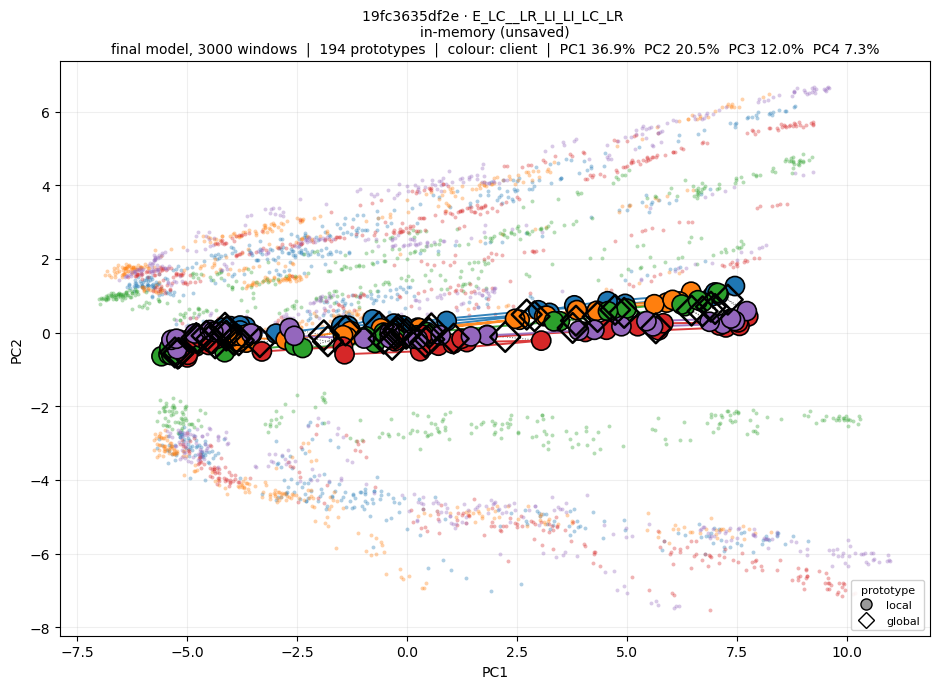

In [31]:
def _colour_of(clients) -> dict: 
    cmap = plt.get_cmap("tab10")
    return {c: cmap(i % 10) for i, c in enumerate(sorted(clients))}


def _scatter(ax, d, E, ix, iy, color_by, size, alpha, fig, colour_of):
    if color_by == "client":
        for c in sorted(d["district"].unique()):
            m = (d["district"] == c).to_numpy()
            ax.scatter(E[m, ix], E[m, iy], s=size, alpha=alpha, color=colour_of[c],
                       label=c, linewidths=0, zorder=2)
        # ax.legend(markerscale=3, fontsize=8, framealpha=.9, loc="upper left")
    else:
        vals = d[color_by].to_numpy()
        cmap, vmin, vmax = ("twilight", 0, 24) if color_by == "hour" \
            else ("YlOrBr", vals.min(), vals.max())
        sc = ax.scatter(E[:, ix], E[:, iy], c=vals, s=size, alpha=alpha, cmap=cmap,
                        vmin=vmin, vmax=vmax, linewidths=0, zorder=2)
        fig.colorbar(sc, ax=ax).set_label(
            "hour of day (window start)" if color_by == "hour" else "model month")


def _bubble(ax, d, E, ix, iy, color_by, n_bins, alpha, fig, colour_of):
    """Grid-aggregate the same points: area ~ count per bin, position = bin mean."""
    x, y = E[:, ix], E[:, iy]
    n_bins = max(2, int(n_bins))
    bx = np.clip(np.digitize(x, np.linspace(x.min(), x.max(), n_bins + 1)) - 1, 0, n_bins - 1)
    by = np.clip(np.digitize(y, np.linspace(y.min(), y.max(), n_bins + 1)) - 1, 0, n_bins - 1)
    bin_id = bx * n_bins + by

    districts = d["district"].to_numpy()
    vals = d[color_by].to_numpy() if color_by != "client" else None
    rows = []
    for b in np.unique(bin_id):
        m = bin_id == b
        if color_by == "client":
            u, c = np.unique(districts[m], return_counts=True)
            v = u[c.argmax()]                       # majority client in the bin
        else:
            v = vals[m].mean()
        rows.append({"x": x[m].mean(), "y": y[m].mean(), "count": int(m.sum()), "value": v})
    bub = pd.DataFrame(rows)

    c = bub["count"].to_numpy()
    size = (np.full(len(c), 150.0) if c.max() == c.min()
            else 30 + 500 * (c - c.min()) / (c.max() - c.min()))
    if color_by == "client":
        ax.scatter(bub["x"], bub["y"], s=size, alpha=alpha, zorder=2,
                   color=[colour_of[v] for v in bub["value"]], edgecolor="black", linewidths=.4)
        # ax.legend(handles=[plt.Line2D([0], [0], marker="o", ls="", color=colour_of[c], label=c)
        #                    for c in sorted(colour_of)],
                #   markerscale=1.3, fontsize=8, framealpha=.9, loc="upper left")
    else:
        cmap, vmin, vmax = ("twilight", 0, 24) if color_by == "hour" \
            else ("YlOrBr", bub["value"].min(), bub["value"].max())
        sc = ax.scatter(bub["x"], bub["y"], s=size, c=bub["value"], alpha=alpha, cmap=cmap,
                        vmin=vmin, vmax=vmax, edgecolor="black", linewidths=.4, zorder=2)
        fig.colorbar(sc, ax=ax).set_label(
            "hour of day (window start)" if color_by == "hour" else "model month")


_PROTO_STYLE = {"local": ("o", 190, "-"), "post_fedavg": ("s", 150, "--"),
                "global": ("D", 230, None)}


def _draw_protos(ax, pr, E, ix, iy, colour_of, traj, links, labels, focus=None):
    """Prototypes on top of the window cloud. `focus` = a month to foreground;
    other months stay as faint context so the trajectory is still readable."""
    if pr is None or not len(pr) or not len(E):
        return []
    P = pr.reset_index(drop=True).assign(x=E[:, ix], y=E[:, iy])
    fc, proxies = FCOLS(P), []

    for scope, (marker, ms, ls) in _PROTO_STYLE.items():
        S = P[P["scope"] == scope]
        if S.empty:
            continue
        on = np.ones(len(S), bool) if focus is None else (S["month"] == focus).to_numpy()
        for sel, a, k in ((~on, .18, .45), (on, 1.0, 1.0)):
            T = S[sel]
            if T.empty:
                continue
            if scope == "global":
                ax.scatter(T["x"], T["y"], s=ms * k, marker=marker, facecolor="none",
                           edgecolor="black", linewidths=1.8 * k, alpha=a, zorder=7)
            else:
                ax.scatter(T["x"], T["y"], s=ms * k, marker=marker, zorder=7,
                           c=[colour_of.get(c, "0.4") for c in T["client"]],
                           edgecolor="black", linewidths=1.2 * k,
                           alpha=a * (1.0 if scope == "local" else .75))
        if traj and scope != "global":
            for c, g in S.groupby("client"):
                g = g.sort_values("month")
                ax.plot(g["x"], g["y"], ls=ls, lw=1.4, zorder=6,
                        alpha=.9 if focus is None else .45, color=colour_of.get(c, "0.4"))
        if labels and scope != "global":
            for r in (S if focus is None else S[on]).itertuples():
                ax.annotate(int(r.month), (r.x, r.y), fontsize=7, zorder=8,
                            xytext=(4, 4), textcoords="offset points")
        proxies.append(plt.Line2D([0], [0], marker=marker, ls="", markersize=8,
                                  markerfacecolor="none" if scope == "global" else "0.6",
                                  markeredgecolor="black", label=scope))

    if links:
        G, L = P[P["scope"] == "global"], P[P["scope"] == "local"]
        shared = sorted(set(G["month"]) & set(L["month"]))
        for m in (shared if focus is None else [f for f in [focus] if f in shared]):
            gm, lm = G[G["month"] == m], L[L["month"] == m]
            A, B = lm[fc].to_numpy(), gm[fc].to_numpy()
            A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
            B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
            for a, k in zip(lm.itertuples(), (A @ B.T).argmax(1)):
                b = gm.iloc[int(k)]
                ax.plot([a.x, b["x"]], [a.y, b["y"]], color="0.35", lw=.7, ls=":", zorder=5)
    return proxies


WORLDS = list_worlds()
if not WORLDS:
    raise RuntimeError("no worlds found (no local data/07_model_output/clients, no experiments cache)")

df_worlds = pd.DataFrame([{"world_id": k, "label": v["label"], **v["meta"]} for k, v in WORLDS.items()]) \
    .set_index("world_id")

df_worlds['tag'] = df_worlds['drift_district'].str[-1] + '_' + df_worlds['drift_to_income'].str[0].str.upper() +  \
    df_worlds['drift_to_land_use'].str[0].str.upper() + '__' + df_worlds['consumption_map']

def _finish(ax, fig, proxies, title, xl, yl, lims, colour_of=None, clients=None):
    """Draws the client-colour and prototype-marker legends.

    Both are built here rather than inside _scatter/_bubble, so the client legend
    survives hiding the window cloud and still appears when the cloud is coloured
    by month or hour while the prototypes are coloured by client.
    """
    if ax.get_legend():
        ax.get_legend().remove()
    if colour_of and clients:
        handles = [plt.Line2D([0], [0], marker="o", ls="", color=colour_of[c], label=c)
                   for c in clients if c in colour_of]
        if handles:      # add_artist BEFORE the second ax.legend call, or it is replaced
            ax.add_artist(ax.legend(handles=handles, fontsize=8, framealpha=.9,
                                    loc="upper left", title="client", title_fontsize=8))
    if proxies:
        ax.legend(handles=proxies, fontsize=8, framealpha=.9, loc="lower right",
                  title="prototype", title_fontsize=8)
    if lims:
        ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1])
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.grid(alpha=.2)
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def plot_all(world_id=None, run_id=None, color_by="client", method="PCA", comp=(1, 2),
             clients=None, month_rng=None, scopes=("local", "global"), max_points=3000,
             size=8, alpha=.35, bubble=False, traj=True, links=True, labels=False,
             fit_on="windows", show_cloud=True, figsize=(9.5, 7)):
    """Every window of the final model + the final-round prototypes, one projection."""
    world_id, run_id = world_id or WORLD_ID, run_id or RUN_ID
    lat = get_tables(world_id, run_id)["latent_trajectories"]
    clients = list(clients) if clients else sorted(lat["district"].unique())
    month_rng = tuple(month_rng) if month_rng else (int(lat["month"].min()),
                                                   int(lat["month"].max()))

    emb = final_embedding(world_id, run_id, method, clients, month_rng, max_points, scopes,
                          fit_on)
    d, Ep = emb["pts"]
    pr, Eq = emb["pro"]
    ix, iy = ((min(comp[0], Ep.shape[1]) - 1, min(comp[1], Ep.shape[1]) - 1)
              if method == "PCA" else (0, 1))
    xl, yl = (f"PC{ix+1}", f"PC{iy+1}") if method == "PCA" else (f"{method} 1", f"{method} 2")

    colour_of = _colour_of(clients)
    fig, ax = plt.subplots(figsize=figsize)
    if show_cloud:
        (_bubble if bubble else _scatter)(ax, d, Ep, ix, iy, color_by, size, alpha, fig, colour_of)
    proxies = _draw_protos(ax, pr, Eq, ix, iy, colour_of, traj, links, labels)
    _finish(ax, fig, proxies,
            f"{world_id[:12]} · {df_worlds.loc[world_id, 'tag']} \n{run_id}\nfinal model, "
            f"{len(d) if show_cloud else 0} windows  |  {len(pr)} prototypes"
            f"  |  colour: {color_by}  |  {emb['sub']}", xl, yl, None)


plot_all()

## 12. Round explorer

Same picture, scrubbable by **round**, on the fixed snapshot subset (the same windows every round,
so the frames are comparable). `round = -1` is the untrained init — it has no prototypes yet.

* **aligned projection** fits one projection over every round at once, so movement between frames
  is real movement and not a re-fit; uncheck it to let each round find its own axes.
* **trajectory** joins each client's prototypes in month order; **links** joins each local
  prototype to its nearest global FINCH cluster.
* `post_fedavg` exists only at the final round — it is the same clients read under the global
  weights, so its offset from `local` is the FedAvg step made visible.

In [32]:
runs = list_runs()
if (WORLD_ID, RUN_ID) not in runs:          # the run in memory, saved or not
    runs = [(WORLD_ID, RUN_ID)] + runs
world_ids = sorted({w for w, _ in runs})
DEFAULT_WORLD, DEFAULT_RUN = WORLD_ID, RUN_ID

def _world_tag(world_id: str) -> str:
    """Readable label for a world; falls back to the short hash when the world
    has no meta (e.g. 'local') or df_worlds hasn't been built."""
    if "df_worlds" in globals() and world_id in df_worlds.index and "tag" in df_worlds.columns:
        t = df_worlds.at[world_id, "tag"]
        if isinstance(t, str) and t:
            return t
    return world_id[:12]


WORLD_OPTIONS = sorted(((_world_tag(w), w) for w in world_ids), key=lambda p: p[0])

def plot_round(world_id, run_id, color_by, method, comp_x, comp_y, clients, month_rng,
               rnd, month, all_months, scopes, align, traj, links, labels, max_points,
               size, alpha, bubble, fit_on, show_cloud):
    clients = list(clients) or sorted(
        get_tables(world_id, run_id)["latent_trajectories"]["district"].unique())
    try:                    # month_rng is the FULL range: the projection must not refit
        emb = round_embedding(world_id, run_id, method, clients, month_rng, max_points,
                              align, scopes, fit_on)
    except ValueError as err:
        print(err); return
    avail = sorted(emb["frames"])
    r = min(avail, key=lambda a: abs(a - rnd))
    d, Ep, pr, Eq = emb["frames"][r]
    focus = None if all_months else int(month)

    ix, iy = ((min(comp_x, Ep.shape[1]) - 1, min(comp_y, Ep.shape[1]) - 1)
              if method == "PCA" else (0, 1))
    xl, yl = (f"PC{ix+1}", f"PC{iy+1}") if method == "PCA" else (f"{method} 1", f"{method} 2")

    if focus is not None:                    # cloud shows the focus month only
        keep = (d["month"] == focus).to_numpy()
        d, Ep = d[keep], Ep[keep]

    colour_of = _colour_of(clients)
    fig, ax = plt.subplots(figsize=(9.5, 7))
    if show_cloud and len(d):
        (_bubble if bubble else _scatter)(ax, d, Ep, ix, iy, color_by, size, alpha, fig, colour_of)
    proxies = _draw_protos(ax, pr, Eq, ix, iy, colour_of, traj, links, labels, focus)
    by_client = len(pr) > 0 and bool((pr["scope"] != "global").any())
    # frame follows what is actually on screen: prototype extent when the cloud is
    # hidden or the map is proto-anchored (the cloud then sprawls far outside it)
    lims = emb["lims_pro"] if (not show_cloud or fit_on == "prototypes") else emb["lims"]
    lims = lims or emb["lims"]
    if not (method == "PCA" and (ix, iy) == (0, 1)):
        lims = None
    tag = f"round {r}" + (" (untrained init)" if r < 0 else "")
    # _finish(ax, fig, proxies,
    #         f"{_world_tag(world_id)[:12]} · {df_worlds.loc[world_id, 'tag']} \n{run_id}\n{tag}  |  "
    #         f"month {'all' if focus is None else focus}  |  "
    #         f"{len(d) if show_cloud else 0} windows  |  {len(pr)} prototypes"
    #         f"  |  colour: {color_by}  |  {emb['sub']}", xl, yl, lims)
    _finish(ax, fig, proxies,
            f"{_world_tag(world_id)[:12]} · {df_worlds.loc[world_id, 'tag']} \n{run_id}\n{tag}  |  "
            f"month {'all' if focus is None else focus}  |  "
            f"{len(d) if show_cloud else 0} windows  |  {len(pr)} prototypes"
            f"  |  colour: {color_by}  |  {emb['sub']}", xl, yl, lims,
            colour_of, clients if (color_by == "client" or by_client) else None)

t0 = get_tables(DEFAULT_WORLD, DEFAULT_RUN)
lat0 = t0["latent_trajectories"]
all_clients = sorted(lat0["district"].unique())
m_lo, m_hi = int(lat0["month"].min()), int(lat0["month"].max())
r_lo, r_hi = ((int(t0["latents_by_round"]["round"].min()), int(t0["latents_by_round"]["round"].max()))
              if t0["latents_by_round"] is not None else (-1, -1))

w_world = widgets.Dropdown(options=WORLD_OPTIONS, value=DEFAULT_WORLD, description="world:",
                           layout=widgets.Layout(width="330px"))
w_run = widgets.Dropdown(options=[r for w, r in runs if w == DEFAULT_WORLD], value=DEFAULT_RUN,
                         description="run:", layout=widgets.Layout(width="430px"))
w_color = widgets.ToggleButtons(options=["client", "month", "hour"], value="client",
                                description="colour by:")
w_method = widgets.Dropdown(options=["PCA", "t-SNE"] + (["UMAP"] if HAS_UMAP else []),
                            value="PCA", description="projection:")
w_fiton = widgets.ToggleButtons(options=["windows", "prototypes"], value="windows",
                                description="fit on:")
w_cx = widgets.IntSlider(value=1, min=1, max=10, description="x comp:")
w_cy = widgets.IntSlider(value=2, min=1, max=10, description="y comp:")
w_clients = widgets.SelectMultiple(options=all_clients, value=tuple(all_clients),
                                   description="clients:", rows=min(6, len(all_clients)))

w_round = widgets.IntSlider(value=r_hi, min=r_lo, max=r_hi, description="round:",
                            continuous_update=False)
w_rplay = widgets.Play(value=r_hi, min=r_lo, max=r_hi, interval=900)
widgets.jslink((w_rplay, "value"), (w_round, "value"))

w_month = widgets.IntSlider(value=m_lo, min=m_lo, max=m_hi, description="month:",
                            continuous_update=False)
w_mplay = widgets.Play(value=m_lo, min=m_lo, max=m_hi, interval=700)
widgets.jslink((w_mplay, "value"), (w_month, "value"))
w_mall = widgets.Checkbox(value=True, description="all months", indent=False)
# the embedding always spans every month, so scrubbing never refits the projection
w_mrange = widgets.IntRangeSlider(value=[m_lo, m_hi], min=m_lo, max=m_hi)   # not displayed

w_scopes = widgets.SelectMultiple(options=SCOPES, value=("local", "global"),
                                  description="protos:", rows=3)
w_align = widgets.Checkbox(value=True, description="aligned projection", indent=False)
w_traj = widgets.Checkbox(value=True, description="trajectory", indent=False)
w_links = widgets.Checkbox(value=True, description="links to global", indent=False)
w_labels = widgets.Checkbox(value=False, description="month labels", indent=False)
w_bubble = widgets.Checkbox(value=False, description="bubble plot", indent=False)
w_cloud = widgets.Checkbox(value=True, description="window cloud", indent=False)
w_size = widgets.IntSlider(value=8, min=1, max=60, description="size:")   # size <-> bins
w_alpha = widgets.FloatSlider(value=.35, min=.05, max=1.0, step=.05, description="alpha:")
w_points = widgets.IntSlider(value=400, min=100, max=1500, step=100, description="pts/round:",
                             continuous_update=False)


def _on_bubble_change(change):
    """Repurposes w_size: point size in scatter mode, bins per axis in bubble mode."""
    lo, hi = (3, 40) if change["new"] else (1, 60)
    w_size.description = "bins:" if change["new"] else "size:"
    if lo > w_size.max:
        w_size.max = hi; w_size.min = lo
    else:
        w_size.min = lo; w_size.max = hi
    w_size.value = min(max(w_size.value, lo), hi)


def _on_mall_change(change):
    for w in (w_month, w_mplay):
        w.disabled = change["new"]


def _set_range(w, lo, hi, value=None):
    w.max = max(hi, w.min); w.min = lo; w.max = hi
    if value is not None:
        w.value = value


def _retarget(world_id, run_id):
    t = get_tables(world_id, run_id)
    lat = t["latent_trajectories"]
    cs = sorted(lat["district"].unique())
    w_clients.options = cs
    w_clients.value = tuple(cs)

    lo, hi = int(lat["month"].min()), int(lat["month"].max())
    _set_range(w_month, lo, hi, lo)
    _set_range(w_mplay, lo, hi, lo)
    w_mrange.max = max(hi, w_mrange.min); w_mrange.min = lo; w_mrange.max = hi
    w_mrange.value = [lo, hi]

    snaps = t["latents_by_round"]
    disabled = snaps is None
    for w in (w_round, w_rplay):
        if not disabled:
            _set_range(w, int(snaps["round"].min()), int(snaps["round"].max()))
        w.disabled = disabled
    if not disabled:
        w_round.value = int(snaps["round"].max())


w_bubble.observe(_on_bubble_change, names="value")
w_mall.observe(_on_mall_change, names="value")
w_world.observe(lambda ch: (setattr(w_run, "options", sorted(r for w, r in runs if w == ch["new"])),
                            setattr(w_run, "value", sorted(r for w, r in runs if w == ch["new"])[0])),
                names="value")
w_run.observe(lambda ch: _retarget(w_world.value, ch["new"]), names="value")
_on_mall_change({"new": w_mall.value})

out = widgets.interactive_output(plot_round, {
    "world_id": w_world, "run_id": w_run, "color_by": w_color, "method": w_method,
    "comp_x": w_cx, "comp_y": w_cy, "clients": w_clients, "month_rng": w_mrange,
    "rnd": w_round, "month": w_month, "all_months": w_mall, "scopes": w_scopes,
    "align": w_align, "traj": w_traj, "links": w_links, "labels": w_labels,
    "max_points": w_points, "size": w_size, "alpha": w_alpha, "bubble": w_bubble,
    "fit_on": w_fiton, "show_cloud": w_cloud,
})

display(widgets.VBox([
    widgets.HBox([w_world, w_run]),
    widgets.HBox([w_color, w_method, w_fiton]),
    widgets.HBox([w_rplay, w_round, w_align]),
    widgets.HBox([w_mplay, w_month, w_mall]),
    widgets.HBox([w_scopes, widgets.VBox([w_traj, w_links, w_labels]),
                  widgets.VBox([w_cloud, w_bubble])]),
    widgets.HBox([w_cx, w_cy, w_points]),
    widgets.HBox([w_clients, widgets.VBox([w_size, w_alpha])]),
]), out)

Output()